# Inferência - Faster R-CNN

Notebook dedicado exclusivamente a inferencia do modelo treinado em imagens de teste e em imagens externas.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "torch": "torch",
    "torchvision": "torchvision",
    "Pillow": "PIL",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "tqdm": "tqdm",
}

missing = [pkg for pkg, module in required_packages.items() if importlib.util.find_spec(module) is None]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("Dependencias instaladas:", ", ".join(missing))
else:
    print("Nenhuma dependencia faltando.")

Nenhuma dependencia faltando.


In [2]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

import torch
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from IPython.display import display

/home/alexandre-oliveira/Projetos/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "pcb-defect-dataset-3800-coco"
TEST_IMAGES_DIR = DATASET_ROOT / "test"

RUNS_DIR = PROJECT_ROOT / "runs" / "detect" / "tcc_pcb_defect_detection" / "fasterrcnn_mobilenet_v3_fpn"
EVAL_OUT_DIR = PROJECT_ROOT / "runs" / "detect" / "eval_results" / "fasterrcnn"
EVAL_OUT_DIR.mkdir(parents=True, exist_ok=True)

if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Diretorio de teste nao encontrado: {TEST_IMAGES_DIR}")

if not RUNS_DIR.exists():
    raise FileNotFoundError(f"Diretorio de runs nao encontrado: {RUNS_DIR}")


def find_latest_run(runs_base):
    run_dirs = [p for p in runs_base.iterdir() if p.is_dir()]
    run_dirs = sorted(run_dirs, key=lambda p: p.stat().st_mtime, reverse=True)

    for run_dir in run_dirs:
        checkpoint_path = run_dir / "best_model.pth"
        class_map_path = run_dir / "class_map.json"
        if checkpoint_path.exists() and class_map_path.exists():
            return run_dir, checkpoint_path, class_map_path

    raise FileNotFoundError("Nenhum run com best_model.pth + class_map.json foi encontrado.")


RUN_DIR, CHECKPOINT_PATH, CLASS_MAP_PATH = find_latest_run(RUNS_DIR)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Run selecionado: {RUN_DIR}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Class map: {CLASS_MAP_PATH}")
print(f"Dispositivo de inferencia: {DEVICE}")

Run selecionado: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/fasterrcnn_mobilenet_v3_fpn/20260424_2257_fasterrcnn_mobilenet_v3_fpn_e50_bs4_seed42_baseline
Checkpoint: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/fasterrcnn_mobilenet_v3_fpn/20260424_2257_fasterrcnn_mobilenet_v3_fpn_e50_bs4_seed42_baseline/best_model.pth
Class map: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/fasterrcnn_mobilenet_v3_fpn/20260424_2257_fasterrcnn_mobilenet_v3_fpn_e50_bs4_seed42_baseline/class_map.json
Dispositivo de inferencia: cuda


In [4]:
with open(CLASS_MAP_PATH, "r", encoding="utf-8") as f:
    class_map_data = json.load(f)

label_to_name = {int(k): v for k, v in class_map_data["label_to_name"].items()}
num_classes = max(label_to_name.keys()) + 1  # inclui background

model = fasterrcnn_mobilenet_v3_large_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

default_score_threshold = float(checkpoint.get("config", {}).get("score_threshold", 0.30))
print(f"Modelo carregado com {num_classes} classes totais.")
print(f"Score threshold padrao: {default_score_threshold:.2f}")

Modelo carregado com 7 classes totais.
Score threshold padrao: 0.30


/tmp/ipykernel_11874/685983442.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")


In [5]:
def load_image_tensor(image_path):
    image = Image.open(image_path).convert("RGB")
    tensor = F.pil_to_tensor(image).float() / 255.0
    return image, tensor


def predict_single_image(image_path, score_threshold=0.30):
    image, tensor = load_image_tensor(image_path)

    with torch.no_grad():
        output = model([tensor.to(DEVICE)])[0]

    keep = output["scores"].detach().cpu() >= score_threshold

    filtered = {
        "boxes": output["boxes"].detach().cpu()[keep],
        "scores": output["scores"].detach().cpu()[keep],
        "labels": output["labels"].detach().cpu()[keep],
    }

    return image, filtered


def draw_predictions(image, prediction, label_to_name):
    annotated = image.copy()
    draw = ImageDraw.Draw(annotated)

    for box, score, label in zip(prediction["boxes"], prediction["scores"], prediction["labels"]):
        x1, y1, x2, y2 = [float(v) for v in box.tolist()]
        label_idx = int(label.item())
        class_name = label_to_name.get(label_idx, f"class_{label_idx}")
        caption = f"{class_name}: {float(score):.2f}"

        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        text_y = y1 - 12 if y1 > 12 else y1 + 2
        draw.text((x1 + 2, text_y), caption, fill="yellow")

    return annotated

In [6]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
test_images = sorted([p for p in TEST_IMAGES_DIR.iterdir() if p.suffix.lower() in image_extensions])

if not test_images:
    raise RuntimeError(f"Nenhuma imagem de teste encontrada em {TEST_IMAGES_DIR}")

sample_size = min(10, len(test_images))
selected_images = sorted(random.sample(test_images, k=sample_size))

score_threshold = default_score_threshold

out_dir = EVAL_OUT_DIR / f"{RUN_DIR.name}_test_predictions"
out_dir.mkdir(parents=True, exist_ok=True)

rows = []

for image_path in tqdm(selected_images, desc="Inferencia no teste"):
    image, prediction = predict_single_image(image_path, score_threshold=score_threshold)
    annotated = draw_predictions(image, prediction, label_to_name)

    annotated_path = out_dir / f"{image_path.stem}_pred.jpg"
    annotated.save(annotated_path)

    boxes = prediction["boxes"]
    scores = prediction["scores"]
    labels = prediction["labels"]

    if len(boxes) == 0:
        rows.append(
            {
                "image_name": image_path.name,
                "class_name": None,
                "score": None,
                "x1": None,
                "y1": None,
                "x2": None,
                "y2": None,
                "annotated_path": str(annotated_path),
            }
        )
        continue

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = [float(v) for v in box.tolist()]
        label_idx = int(label.item())

        rows.append(
            {
                "image_name": image_path.name,
                "class_name": label_to_name.get(label_idx, f"class_{label_idx}"),
                "score": float(score.item()),
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "annotated_path": str(annotated_path),
            }
        )

pred_df = pd.DataFrame(rows)
pred_csv_path = out_dir / "predicoes_detalhadas.csv"
pred_df.to_csv(pred_csv_path, index=False)

summary_df = (
    pred_df.dropna(subset=["class_name"])
    .groupby("class_name")
    .size()
    .reset_index(name="detections")
    .sort_values("detections", ascending=False)
)
summary_csv_path = out_dir / "resumo_por_classe.csv"
summary_df.to_csv(summary_csv_path, index=False)

print(f"Imagens processadas: {len(selected_images)}")
print(f"Total de imagens disponiveis no teste: {len(test_images)}")
print(f"Diretorio de saida: {out_dir}")
print(f"Tabela detalhada: {pred_csv_path}")
print(f"Resumo por classe: {summary_csv_path}")

display(summary_df)

Inferencia no teste: 100%|██████████| 10/10 [00:00<00:00, 10.34it/s]

Imagens processadas: 10
Total de imagens disponiveis no teste: 413
Diretorio de saida: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/eval_results/fasterrcnn/20260424_2257_fasterrcnn_mobilenet_v3_fpn_e50_bs4_seed42_baseline_test_predictions
Tabela detalhada: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/eval_results/fasterrcnn/20260424_2257_fasterrcnn_mobilenet_v3_fpn_e50_bs4_seed42_baseline_test_predictions/predicoes_detalhadas.csv
Resumo por classe: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/eval_results/fasterrcnn/20260424_2257_fasterrcnn_mobilenet_v3_fpn_e50_bs4_seed42_baseline_test_predictions/resumo_por_classe.csv


,class_name,detections
5,spurious_copper,5
1,mouse_bite,4
0,missing_hole,2
3,short,2
4,spur,2
2,open_circuit,1


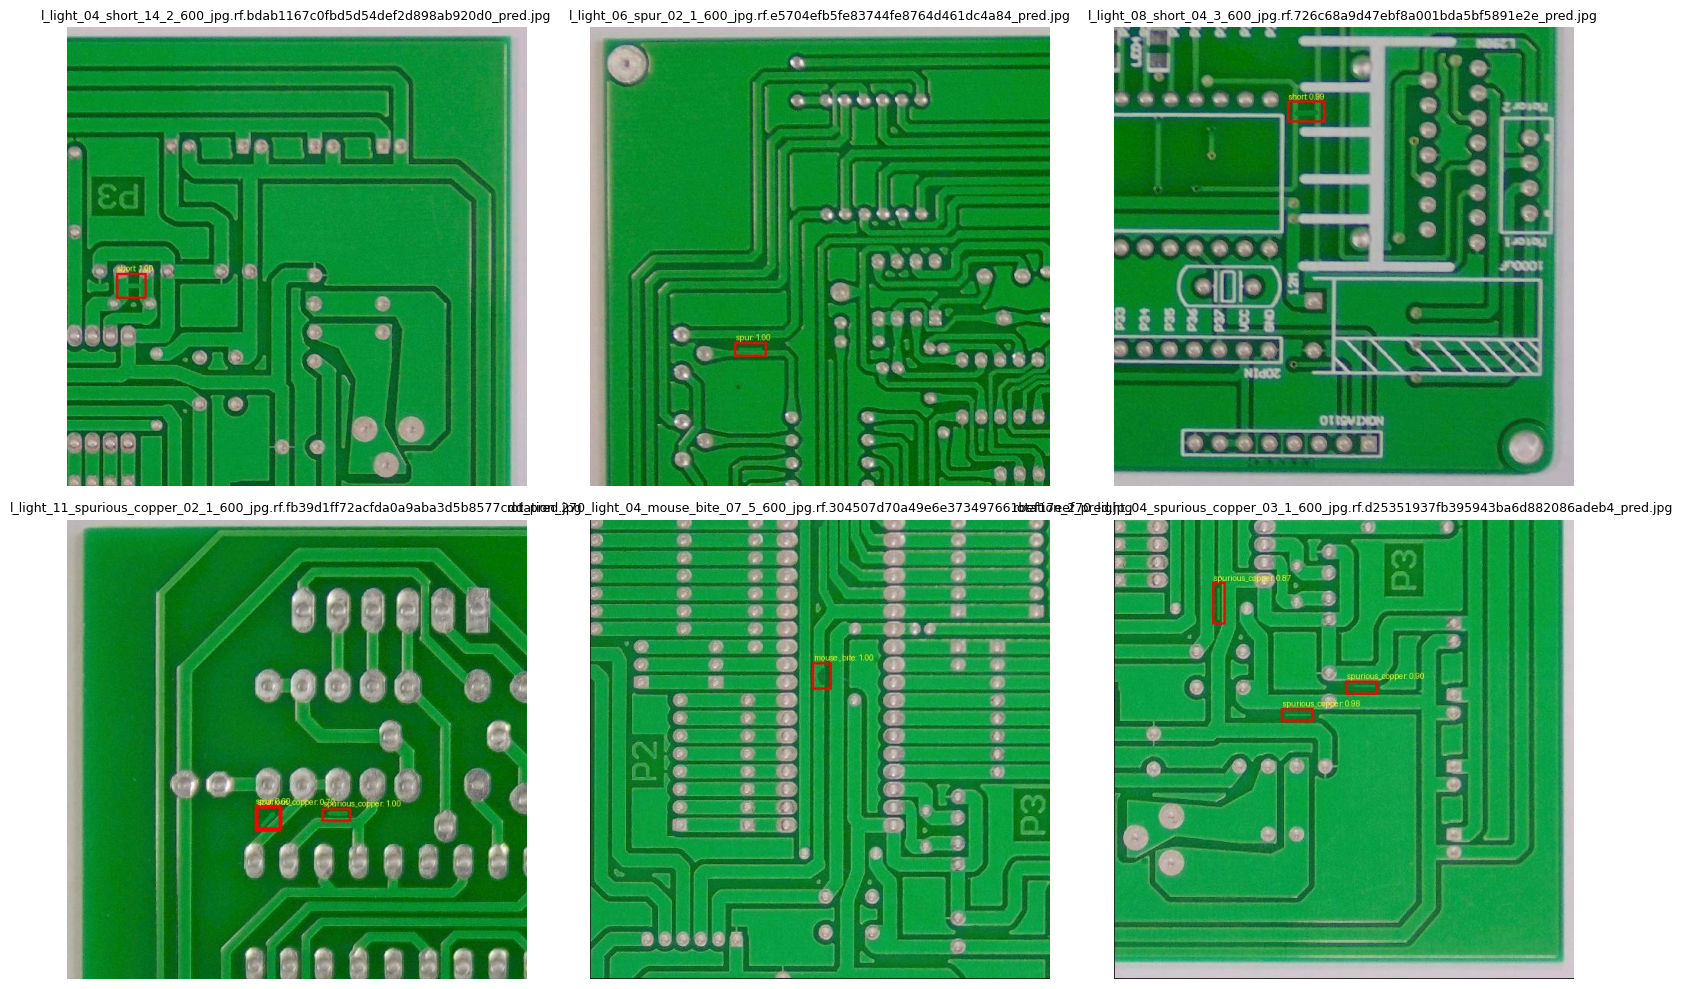

In [7]:
sample_pred_images = sorted(out_dir.glob("*_pred.jpg"))[:6]

if not sample_pred_images:
    print("Nenhuma imagem anotada foi gerada.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < len(sample_pred_images):
            img = Image.open(sample_pred_images[i]).convert("RGB")
            ax.imshow(np.array(img))
            ax.set_title(sample_pred_images[i].name, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()